# Weather & Supplementary Data Collection
### Intraday Power Market Analysis | AT & DE | Phase 1

This notebook collects all external data needed for Phase 3 (weather impact analysis):

1. **Weather data** — solar irradiance, wind speed, temperature, cloud cover (open-meteo)
2. **Day-ahead prices** — ENTSO-E Transparency Platform
3. **Renewable generation** — actual wind and solar generation (ENTSO-E)
4. **Load (demand)** — actual total load (ENTSO-E)

All data is saved to `../data/external/processed/` as Parquet files, aligned to hourly
resolution to match the intraday trade data.

**Data period:** January 1 2024 → July 5 2024 (covers full AT trade window)

> **No API keys required for open-meteo.** ENTSO-E requires a free API key —
> register at https://transparency.entsoe.eu and set it in the config cell below.

## 1. Setup

Install dependencies if not already present. `openmeteo-requests` is the official
Python client for the open-meteo API. `requests-cache` reduces API calls by caching
responses locally.

In [71]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", 
                "openmeteo-requests", "requests-cache", 
                "retry-requests", "entsoe-py", "-q"], check=True)
print("Done")

Done



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [72]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import openmeteo_requests
import requests_cache
from retry_requests import retry

# ── Output folder ─────────────────────────────────────────────────────────
os.makedirs("../data/external/processed", exist_ok=True)

# ── Date range ────────────────────────────────────────────────────────────
START_DATE = "2024-01-01"
END_DATE   = "2025-07-05"

# ── ENTSO-E API key — loaded from .env ───────────────────────────────────
load_dotenv("../.env")
ENTSOE_API_KEY = os.getenv("ENTSOE_API_KEY", "")

print(f"Date range: {START_DATE} → {END_DATE}")
print(f"Output: ../data/external/processed/")

Date range: 2024-01-01 → 2025-07-05
Output: ../data/external/processed/


## 2. Weather Data — open-meteo

open-meteo provides free historical weather data at hourly resolution with no API key.
Data is sourced from ERA5 reanalysis (ECMWF) which is the standard for energy market
weather analysis.

**Locations chosen:**
- **Austria:** Vienna (48.21°N, 16.37°E) — central location representative of AT load centre
- **Germany:** Frankfurt (50.11°N, 8.68°E) — central DE, representative of CWE region

**Variables collected:**
- `shortwave_radiation` — global horizontal irradiance (W/m²), proxy for solar generation
- `wind_speed_100m` — wind speed at 100m hub height (m/s), relevant for wind turbines
- `temperature_2m` — air temperature (°C), drives heating/cooling demand
- `cloud_cover` — total cloud cover (%), affects solar output
- `precipitation` — hourly precipitation (mm), correlated with overcast conditions

In [73]:
# Set up cached session to avoid re-downloading on re-runs
cache_session = requests_cache.CachedSession('.openmeteo_cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)

LOCATIONS = {
    "AT": [
        {"latitude": 48.21, "longitude": 16.37, "name": "Vienna"},
        {"latitude": 47.27, "longitude": 11.40, "name": "Innsbruck"},
        {"latitude": 47.07, "longitude": 15.44, "name": "Graz"},
    ],
    "DE": [
        {"latitude": 53.55, "longitude": 10.00, "name": "Hamburg"},
        {"latitude": 52.52, "longitude": 13.40, "name": "Berlin"},
        {"latitude": 50.11, "longitude": 8.68,  "name": "Frankfurt"},
        {"latitude": 48.14, "longitude": 11.58, "name": "Munich"},
        {"latitude": 48.78, "longitude": 9.18,  "name": "Stuttgart"},
    ],
}

WEATHER_VARS = [
    "shortwave_radiation",
    "wind_speed_100m",
    "temperature_2m",
    "cloud_cover",
    "precipitation",
]

weather_dfs = {}

for market, locations in LOCATIONS.items():
    print(f"Downloading weather for {market} ({len(locations)} locations)...")
    
    market_frames = []
    for loc in locations:
        params = {
            "latitude":   loc["latitude"],
            "longitude":  loc["longitude"],
            "start_date": START_DATE,
            "end_date":   END_DATE,
            "hourly":     WEATHER_VARS,
            "timezone":   "Europe/Vienna",
            "wind_speed_unit": "ms",
        }
        
        responses = om.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
        response  = responses[0]
        hourly    = response.Hourly()
        
        df_loc = pd.DataFrame({
            "time": pd.date_range(
                start=pd.Timestamp(hourly.Time(), unit='s', tz='Europe/Vienna'),
                end=pd.Timestamp(hourly.TimeEnd(), unit='s', tz='Europe/Vienna'),
                freq=pd.Timedelta(seconds=hourly.Interval()),
                inclusive='left'
            ),
            "shortwave_radiation": hourly.Variables(0).ValuesAsNumpy(),
            "wind_speed_100m":     hourly.Variables(1).ValuesAsNumpy(),
            "temperature_2m":      hourly.Variables(2).ValuesAsNumpy(),
            "cloud_cover":         hourly.Variables(3).ValuesAsNumpy(),
            "precipitation":       hourly.Variables(4).ValuesAsNumpy(),
        })
        df_loc["location"] = loc["name"]
        market_frames.append(df_loc)
        print(f"  {loc['name']}: {len(df_loc):,} rows")
    
    # Average across all locations — simple unweighted mean per hour
    all_locs = pd.concat(market_frames)
    avg = (
        all_locs.groupby("time")[WEATHER_VARS]
        .mean()
        .reset_index()
    )
    avg["market"] = market
    weather_dfs[market] = avg
    
    print(f"  {market} averaged: {len(avg):,} rows\n")

print("Weather download complete.")

  Vienna: 13,248 rows
  Innsbruck: 13,248 rows
  Graz: 13,248 rows
  AT averaged: 13,248 rows

  Hamburg: 13,248 rows
  Berlin: 13,248 rows
  Frankfurt: 13,248 rows
  Munich: 13,248 rows
  Stuttgart: 13,248 rows
  DE averaged: 13,248 rows

Weather download complete.


In [74]:
# Quick sanity check — print stats
for market, df in weather_dfs.items():
    print(f"=== {market} Weather ===")
    print(f"  Rows          : {len(df):,}")
    print(f"  Nulls         : {df.isnull().sum().sum()}")
    print(f"  Radiation max : {df['shortwave_radiation'].max():.1f} W/m²")
    print(f"  Wind max      : {df['wind_speed_100m'].max():.1f} m/s")
    print(f"  Temp range    : {df['temperature_2m'].min():.1f} → {df['temperature_2m'].max():.1f} °C")
    print()

=== AT Weather ===
  Rows          : 13,248
  Nulls         : 0
  Radiation max : 910.3 W/m²
  Wind max      : 13.5 m/s
  Temp range    : -8.8 → 32.4 °C

=== DE Weather ===
  Rows          : 13,248
  Nulls         : 0
  Radiation max : 882.4 W/m²
  Wind max      : 15.1 m/s
  Temp range    : -8.1 → 35.9 °C



In [75]:
# Save weather data
for market, df in weather_dfs.items():
    path = f"../data/external/processed/weather_{market}.parquet"
    df.to_parquet(path, index=False, engine='pyarrow', compression='snappy')
    size = os.path.getsize(path) / 1e6
    print(f"Saved {market} weather → {path} ({size:.1f} MB)")

Saved AT weather → ../data/external/processed/weather_AT.parquet (0.3 MB)
Saved DE weather → ../data/external/processed/weather_DE.parquet (0.3 MB)


## 3. ENTSO-E Data

The ENTSO-E Transparency Platform publishes official European power system data.
The `entsoe-py` library provides a clean Python interface.

**Data collected:**
- Day-ahead prices (€/MWh) — for AT and DE
- Actual wind and solar generation (MW) — for AT and DE
- Actual total load / demand (MW) — for AT and DE

**Why day-ahead prices?**  
The spread between day-ahead and intraday prices is a key analytical target in
Phase 2. Day-ahead prices are set the evening before delivery; intraday prices
update continuously as new information (weather forecasts, outages) arrives.
The spread measures how much forecast error drove re-trading.

> **Prerequisite:** Replace `YOUR_API_KEY_HERE` in the config cell with your
> ENTSO-E API key before running this section.

In [76]:
from entsoe import EntsoePandasClient
import pandas as pd

# Skip this section if no API key provided
if not ENTSOE_API_KEY:
    print("⚠ ENTSO-E API key not set — skipping ENTSO-E download.")
    print("  Register at https://transparency.entsoe.eu and set ENTSOE_API_KEY above.")
else:
    client = EntsoePandasClient(api_key=ENTSOE_API_KEY)

    start = pd.Timestamp(START_DATE, tz='Europe/Vienna')
    end   = pd.Timestamp(END_DATE,   tz='Europe/Vienna')

    # EIC codes for bidding zones
    ZONES = {"AT": "10YAT-APG------L", "DE": "10Y1001A1001A82H"}

    entsoe_data = {}

    for market, zone in ZONES.items():
        print(f"Downloading ENTSO-E data for {market}...")
        data = {}

        # Day-ahead prices
        try:
            da = client.query_day_ahead_prices(zone, start=start, end=end)
            da.name = "day_ahead_price"
            data["day_ahead_price"] = da
            print(f"  Day-ahead prices: {len(da):,} records")
        except Exception as e:
            print(f"  Day-ahead prices failed: {e}")

        # Actual generation by source
        try:
            gen = client.query_generation(zone, start=start, end=end, psr_type=None)
            data["generation"] = gen
            print(f"  Generation: {gen.shape}")
        except Exception as e:
            print(f"  Generation failed: {e}")

        # Actual load
        try:
            load = client.query_load(zone, start=start, end=end)
            load.name = "actual_load"
            data["load"] = load
            print(f"  Load: {len(load):,} records")
        except Exception as e:
            print(f"  Load failed: {e}")

        entsoe_data[market] = data
        print(f"  {market} done\n")

    print("ENTSO-E download complete.")

  Day-ahead prices: 13,223 records
  Generation: (52891, 26)
  Load: 52,891 records
  AT done

  Day-ahead prices: 13,223 records
  Generation: (52891, 19)
  Load: 52,891 records
  DE done

ENTSO-E download complete.


In [77]:
# Save ENTSO-E data (only runs if API key was set)
if ENTSOE_API_KEY:
    for market, data in entsoe_data.items():

        # Day-ahead prices
        if "day_ahead_price" in data:
            da = data["day_ahead_price"].reset_index()
            da.columns = ["time", "day_ahead_price"]
            da["market"] = market
            path = f"../data/external/processed/day_ahead_price_{market}.parquet"
            da.to_parquet(path, index=False, engine='pyarrow', compression='snappy')
            print(f"Saved day-ahead prices {market} → {path}")

        # Generation
        if "generation" in data:
            gen = data["generation"].reset_index()
            gen["market"] = market
            path = f"../data/external/processed/generation_{market}.parquet"
            gen.to_parquet(path, index=False, engine='pyarrow', compression='snappy')
            print(f"Saved generation {market} → {path}")

        # Load
        if "load" in data:
            ld = data["load"].reset_index()
            ld.columns = ["time", "actual_load"]
            ld["market"] = market
            path = f"../data/external/processed/load_{market}.parquet"
            ld.to_parquet(path, index=False, engine='pyarrow', compression='snappy')
            print(f"Saved load {market} → {path}")
else:
    print("Skipped — set ENTSOE_API_KEY to download ENTSO-E data.")

Saved day-ahead prices AT → ../data/external/processed/day_ahead_price_AT.parquet
Saved generation AT → ../data/external/processed/generation_AT.parquet
Saved load AT → ../data/external/processed/load_AT.parquet
Saved day-ahead prices DE → ../data/external/processed/day_ahead_price_DE.parquet
Saved generation DE → ../data/external/processed/generation_DE.parquet
Saved load DE → ../data/external/processed/load_DE.parquet


## 4. Quick Visual Check

Before finishing, plot the weather variables to confirm the data looks physically
reasonable. Solar radiation should peak in summer midday hours, wind should show
no systematic trend, and temperature should follow a clear seasonal pattern.

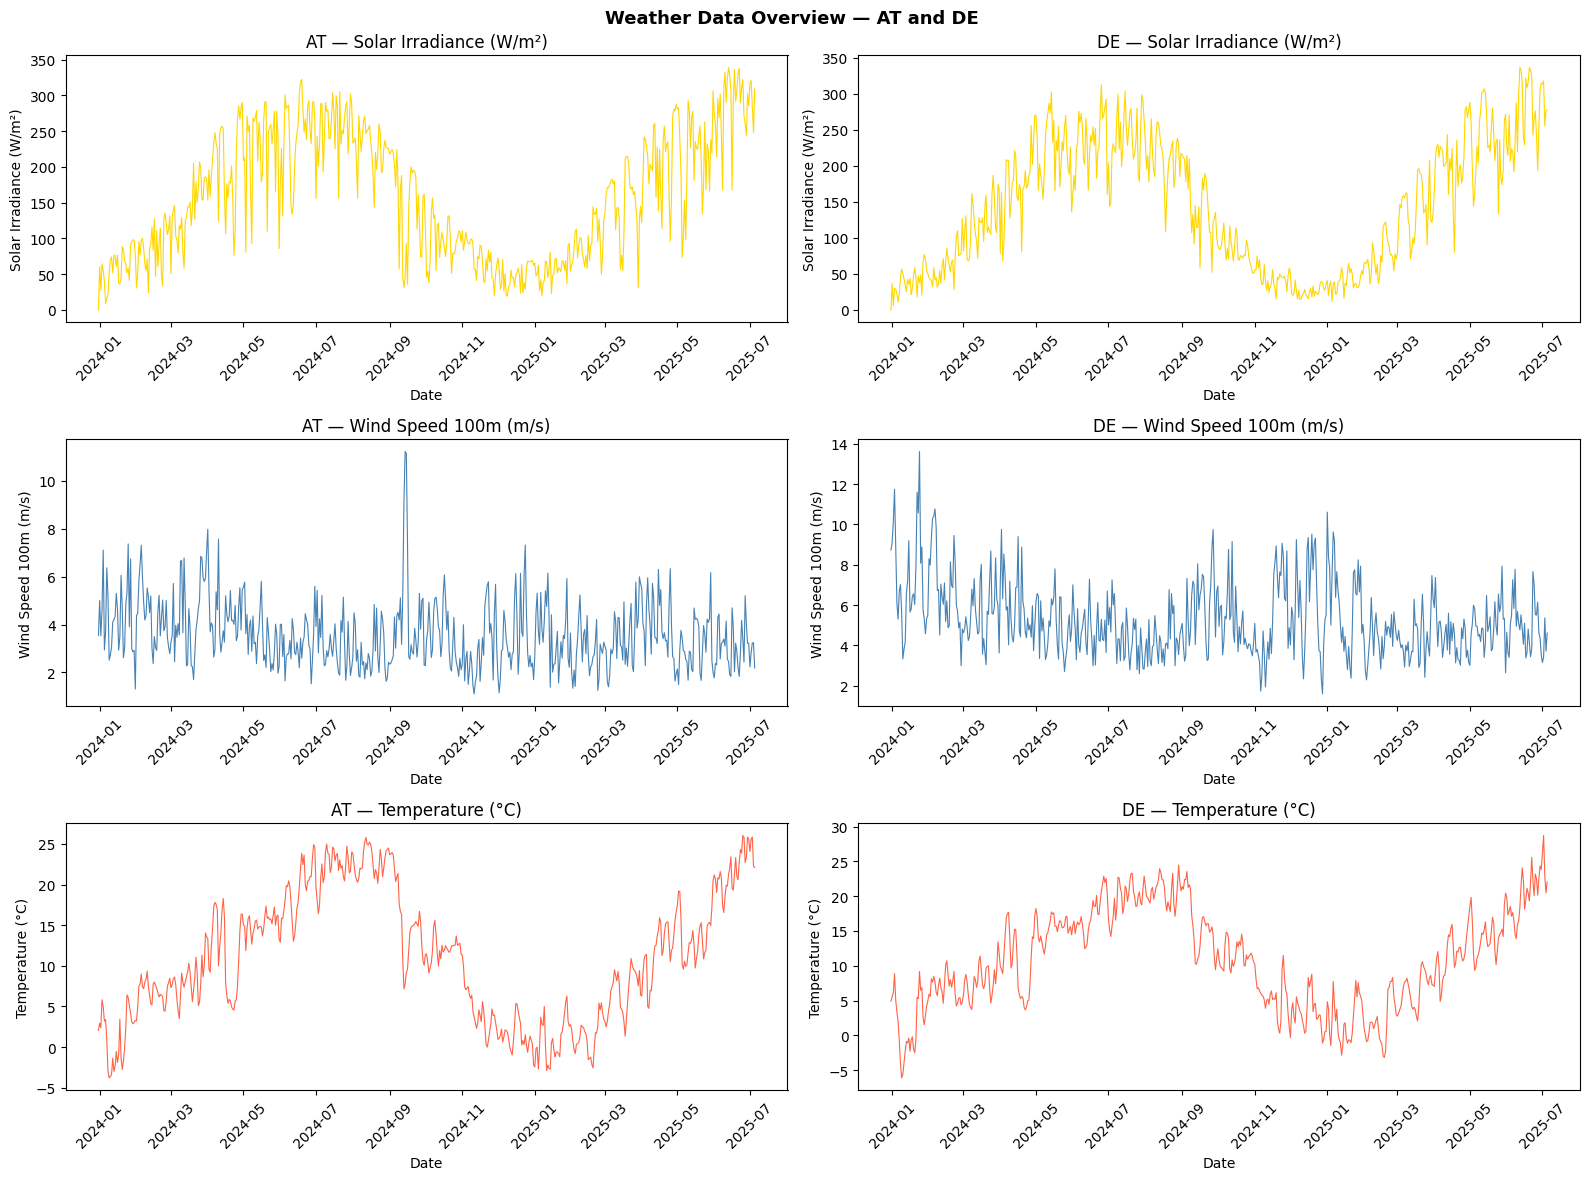

Saved → ../reports/weather_overview.png


In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Weather Data Overview — AT and DE ",
             fontsize=13, fontweight='bold')

plot_vars = [
    ("shortwave_radiation", "Solar Irradiance (W/m²)", "gold"),
    ("wind_speed_100m",     "Wind Speed 100m (m/s)",   "steelblue"),
    ("temperature_2m",      "Temperature (°C)",        "tomato"),
]

for row, (var, label, color) in enumerate(plot_vars):
    for col, market in enumerate(['AT', 'DE']):
        df = weather_dfs[market]
        ax = axes[row, col]
        # Daily mean for readability
        daily = df.set_index("time")[var].resample("D").mean()
        ax.plot(daily.index, daily.values, linewidth=0.8, color=color)
        ax.set_title(f"{market} — {label}")
        ax.set_xlabel("Date")
        ax.set_ylabel(label)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/weather_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../reports/weather_overview.png')

+rain

## 5. Data Inventory

Summary of all files now available for Phase 3 analysis.

In [79]:
print('=== Processed Data Inventory ===')
print()

folders = [
    ("../data/AT/processed",       "AT Trade Data"),
    ("../data/DE/processed",       "DE Trade Data"),
    ("../data/external/processed", "External Data"),
]

for folder, label in folders:
    print(f"--- {label} ---")
    if os.path.exists(folder):
        for fname in sorted(os.listdir(folder)):
            if fname.endswith(".parquet"):
                fpath = os.path.join(folder, fname)
                size  = os.path.getsize(fpath) / 1e6
                try:
                    import pyarrow.parquet as pq
                    rows = pq.read_metadata(fpath).num_rows
                    print(f"  {fname:<50} {size:>6.1f} MB  |  {rows:>10,} rows")
                except Exception:
                    print(f"  {fname:<50} {size:>6.1f} MB")
    else:
        print(f"  (folder not found)")
    print()

=== Processed Data Inventory ===

--- AT Trade Data ---
  intraday_trades_AT.parquet                           69.8 MB  |   3,664,611 rows

--- DE Trade Data ---
  intraday_trades_DE.parquet                          168.5 MB  |   9,056,883 rows

--- External Data ---
  crossborder_flow_AT_DE.parquet                        0.8 MB  |      52,891 rows
  crossborder_flow_DE_AT.parquet                        0.8 MB  |      52,891 rows
  day_ahead_price_AT.parquet                            0.2 MB  |      13,223 rows
  day_ahead_price_DE.parquet                            0.2 MB  |      13,223 rows
  generation_AT.parquet                                 1.1 MB  |      52,891 rows
  generation_AT_clean.parquet                           1.0 MB  |      52,891 rows
  generation_DE.parquet                                 5.1 MB  |      52,891 rows
  generation_DE_clean.parquet                           4.7 MB  |      52,891 rows
  load_AT.parquet                                       0.6 MB  |   

## 6. Next Steps — Phase 3

With all data collected and saved, Phase 3 (Weather & Forecast Impact Analysis)
can begin. The workflow will be:

1. **Align data** — resample intraday trades to hourly VWAP, join with hourly
   weather data on the `time` column
2. **Correlation analysis** — Pearson and Spearman correlations between weather
   variables and hourly VWAP
3. **Negative price drivers** — logistic regression / random forest to predict
   negative price hours from weather + load features
4. **Day-ahead vs intraday spread** — regress the DA/ID spread against weather
   forecast errors (requires NWP forecast data from ECMWF or DWD)
5. **Event analysis** — identify Dunkelflaute periods (dark doldrums) and
   extreme solar days, compare price behaviour

**Key join logic:**
```python
# Aggregate intraday trades to hourly VWAP
vwap_hourly = (
    df_at.groupby(df_at['time'].dt.floor('h'))
    .apply(lambda g: np.average(g['price'], weights=g['quantity']))
    .rename('vwap')
    .reset_index()
)

# Join with weather
weather_at = pd.read_parquet('../data/external/processed/weather_AT.parquet')
merged = vwap_hourly.merge(weather_at, on='time', how='inner')
```

In [80]:
import pyarrow.parquet as pq
import os

for market in ["AT", "DE"]:
    path = f"../data/external/processed/weather_{market}.parquet"
    if os.path.exists(path):
        meta = pq.read_metadata(path)
        size = os.path.getsize(path) / 1e6
        print(f"weather_{market}: {meta.num_rows:,} rows | {size:.1f} MB")
    else:
        print(f"weather_{market}: NOT FOUND")

weather_AT: 13,248 rows | 0.3 MB
weather_DE: 13,248 rows | 0.3 MB


In [81]:
# Cross-border physical flows AT↔DE
print("Downloading cross-border flows...")

flow_data = {}
BORDERS = {
    "AT_DE": ("10YAT-APG------L", "10Y1001A1001A82H"),
    "DE_AT": ("10Y1001A1001A82H", "10YAT-APG------L"),
}

for name, (from_zone, to_zone) in BORDERS.items():
    try:
        flows = client.query_crossborder_flows(
            country_code_from=from_zone,
            country_code_to=to_zone,
            start=start, end=end
        )
        flows.name = f"flow_{name}"
        flow_data[name] = flows
        print(f"  {name}: {len(flows):,} records")
    except Exception as e:
        print(f"  {name} failed: {e}")

# Save
for name, series in flow_data.items():
    df = series.reset_index()
    df.columns = ["time", "flow_mw"]
    df["direction"] = name
    path = f"../data/external/processed/crossborder_flow_{name}.parquet"
    df.to_parquet(path, index=False, engine="pyarrow", compression="snappy")
    print(f"Saved → {path}")

  AT_DE: 52,891 records
  DE_AT: 52,891 records
Saved → ../data/external/processed/crossborder_flow_AT_DE.parquet
Saved → ../data/external/processed/crossborder_flow_DE_AT.parquet


In [82]:
import pyarrow as pa
import pyarrow.parquet as pq

def read_parquet_safe(path):
    """Read parquet avoiding pyarrow timezone compatibility issues."""
    table = pq.read_table(path)
    # Convert timezone-aware timestamps to UTC strings then re-parse
    df = table.to_pandas(timestamp_as_object=True)
    # Fix any datetime columns
    for col in df.columns:
        if df[col].dtype == object:
            try:
                sample = df[col].dropna().iloc[0]
                if hasattr(sample, 'tzinfo'):
                    df[col] = pd.to_datetime(df[col], utc=True).dt.tz_convert("Europe/Vienna")
            except (IndexError, TypeError):
                pass
    return df

da_at   = read_parquet_safe("../data/external/processed/day_ahead_price_AT.parquet")
da_de   = read_parquet_safe("../data/external/processed/day_ahead_price_DE.parquet")
gen_at  = read_parquet_safe("../data/external/processed/generation_AT.parquet")
gen_de  = read_parquet_safe("../data/external/processed/generation_DE.parquet")
load_at = read_parquet_safe("../data/external/processed/load_AT.parquet")
load_de = read_parquet_safe("../data/external/processed/load_DE.parquet")
wx_at = read_parquet_safe("../data/external/processed/weather_AT.parquet")
wx_de = read_parquet_safe("../data/external/processed/weather_DE.parquet")

print("All external data loaded.")
for name, df in [("DA price AT", da_at), ("DA price DE", da_de),
                 ("Generation AT", gen_at), ("Generation DE", gen_de),
                 ("Load AT", load_at), ("Load DE", load_de),
                 ("Weather AT", wx_at), ("Weather DE", wx_de)]:
    print(f"  {name:<20} {len(df):>8,} rows | cols: {list(df.columns)}")

All external data loaded.
  DA price AT            13,223 rows | cols: ['time', 'day_ahead_price', 'market']
  DA price DE            13,223 rows | cols: ['time', 'day_ahead_price', 'market']
  Generation AT          52,891 rows | cols: ["('index', '')", "('Biomass', 'Actual Aggregated')", "('Biomass', 'Actual Consumption')", "('Fossil Gas', 'Actual Aggregated')", "('Fossil Gas', 'Actual Consumption')", "('Fossil Hard coal', 'Actual Aggregated')", "('Fossil Hard coal', 'Actual Consumption')", "('Fossil Oil', 'Actual Aggregated')", "('Fossil Oil', 'Actual Consumption')", "('Geothermal', 'Actual Aggregated')", "('Geothermal', 'Actual Consumption')", "('Hydro Pumped Storage', 'Actual Aggregated')", "('Hydro Pumped Storage', 'Actual Consumption')", "('Hydro Run-of-river and poundage', 'Actual Aggregated')", "('Hydro Run-of-river and poundage', 'Actual Consumption')", "('Hydro Water Reservoir', 'Actual Aggregated')", "('Hydro Water Reservoir', 'Actual Consumption')", "('Other', 'Actual Aggr

In [87]:
print(gen_at.columns.tolist())
print(gen_at.head(2))

['time', 'biomass', 'fossil_gas', 'fossil_hard_coal', 'fossil_oil', 'geothermal', 'hydro_pumped_storage', 'hydro_run-of-river_and_poundage', 'hydro_water_reservoir', 'other', 'other_renewable', 'solar', 'waste', 'wind_onshore', 'market', 'total_renewable', 'total_fossil']
                       time  biomass  fossil_gas  fossil_hard_coal  \
0 2024-01-01 00:00:00+01:00    144.0        33.6               0.0   
1 2024-01-01 00:15:00+01:00    144.0        32.8               0.0   

   fossil_oil  geothermal  hydro_pumped_storage  \
0         0.0        0.07                   0.0   
1         0.0        0.07                   0.0   

   hydro_run-of-river_and_poundage  hydro_water_reservoir  other  \
0                           3943.6                  231.6   22.0   
1                           4004.4                  194.0   22.0   

   other_renewable  solar  waste  wind_onshore market  total_renewable  \
0              0.0    0.0  100.0         776.0     AT           4951.2   
1        

In [86]:
def clean_generation(df, market):
    """Flatten MultiIndex columns from ENTSO-E generation data."""
    
    # Find the time column
    time_col = [c for c in df.columns if 'index' in str(c)][0]
    df = df.rename(columns={time_col: "time"})
    
    # Rename tuple columns to clean strings
    new_cols = {}
    for col in df.columns:
        if col in ["time", "market"]:
            continue
        # Parse tuple string like "('Solar', 'Actual Aggregated')"
        try:
            import ast
            t = ast.literal_eval(col)
            # Keep only Actual Aggregated (generation), not Consumption
            if "Actual Aggregated" in t[1]:
                new_cols[col] = t[0].replace(" ", "_").replace("/", "_").lower()
        except:
            pass
    
    # Keep only aggregated generation columns + time + market
    keep_cols = ["time", "market"] + list(new_cols.keys())
    df = df[[c for c in keep_cols if c in df.columns]].rename(columns=new_cols)
    
    # Fill NaN with 0 (source not active in that hour)
    gen_cols = [c for c in df.columns if c not in ["time", "market"]]
    df[gen_cols] = df[gen_cols].fillna(0)
    
    df["market"] = market
    return df

gen_at = clean_generation(gen_at, "AT")
gen_de = clean_generation(gen_de, "DE")

print("AT generation columns:", list(gen_at.columns))
print("DE generation columns:", list(gen_de.columns))
print()
print(gen_at.head(3))

IndexError: list index out of range

In [88]:
# Save cleaned generation
gen_at.to_parquet("../data/external/processed/generation_AT_clean.parquet",
                  index=False, engine="pyarrow", compression="snappy")
gen_de.to_parquet("../data/external/processed/generation_DE_clean.parquet",
                  index=False, engine="pyarrow", compression="snappy")
print("Saved cleaned generation files")

# Add total renewable and total fossil columns — useful for Phase 3
for name, df in [("AT", gen_at), ("DE", gen_de)]:
    renewable_cols_at = ["solar", "wind_onshore", "hydro_run-of-river_and_poundage",
                         "hydro_water_reservoir", "other_renewable"]
    renewable_cols_de = ["solar", "wind_onshore", "wind_offshore",
                         "hydro_run-of-river_and_poundage", "hydro_water_reservoir",
                         "other_renewable"]
    
    renewable_cols = renewable_cols_de if name == "DE" else renewable_cols_at
    available = [c for c in renewable_cols if c in df.columns]
    df["total_renewable"] = df[available].sum(axis=1)
    
    fossil_cols = [c for c in df.columns if "fossil" in c]
    df["total_fossil"] = df[fossil_cols].sum(axis=1)
    
    print(f"{name} — renewable max: {df['total_renewable'].max():.0f} MW, "
          f"fossil max: {df['total_fossil'].max():.0f} MW")

Saved cleaned generation files
AT — renewable max: 10608 MW, fossil max: 7471 MW
DE — renewable max: 68836 MW, fossil max: 94026 MW


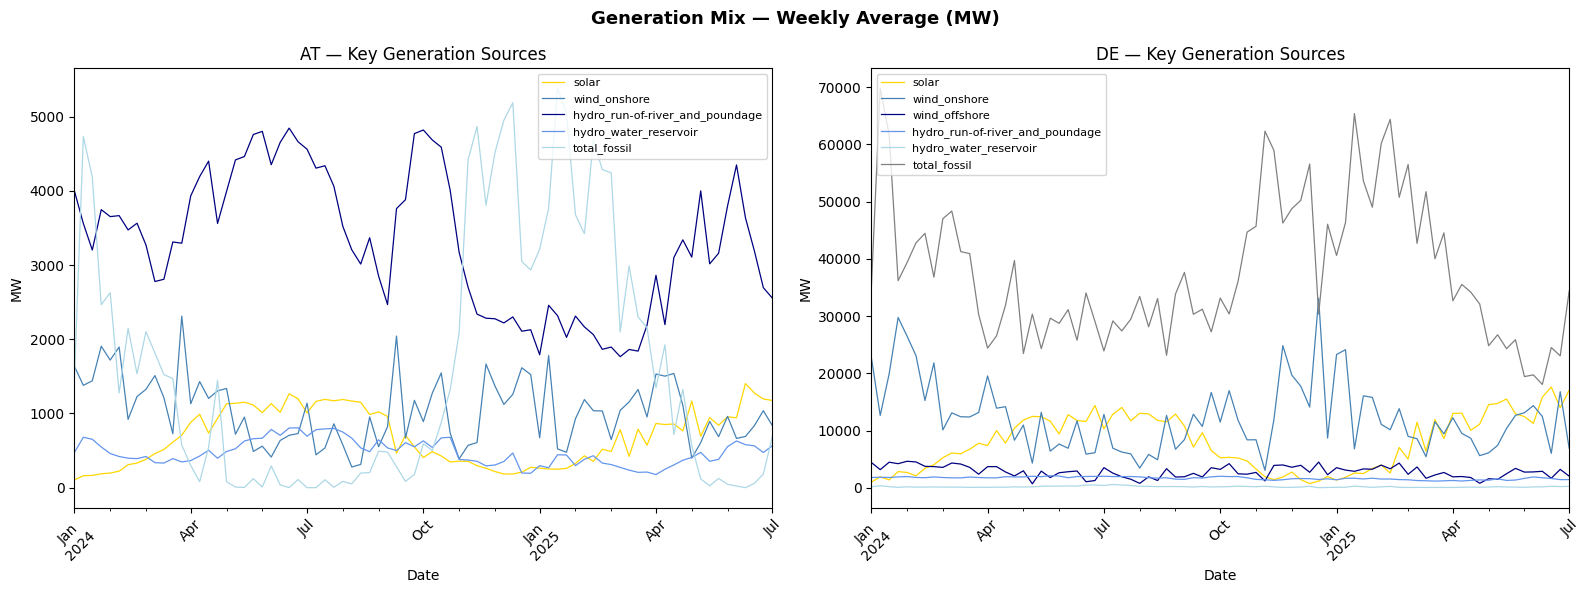

Saved → ../reports/generation_mix.png


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Generation Mix — Weekly Average (MW)", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("AT", gen_at), ("DE", gen_de)]):
    plot_cols = ["solar", "wind_onshore", "hydro_run-of-river_and_poundage",
                 "hydro_water_reservoir", "total_fossil"]
    if name == "DE":
        plot_cols.insert(2, "wind_offshore")
    
    available = [c for c in plot_cols if c in df.columns]
    df_daily = df.set_index("time")[available].resample("W").mean()
    
    colors = ["gold", "steelblue", "navy", "cornflowerblue", "lightblue", "gray"]
    df_daily.plot(ax=ax, linewidth=0.9, color=colors[:len(available)])
    ax.set_title(f"{name} — Key Generation Sources")
    ax.set_xlabel("Date")
    ax.set_ylabel("MW")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/generation_mix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/generation_mix.png")

In [93]:
df_at_trades = read_parquet_safe("../data/AT/processed/intraday_trades_AT.parquet")
df_de_trades = read_parquet_safe("../data/DE/processed/intraday_trades_DE.parquet")

print(f"AT trades: {len(df_at_trades):,} rows")
print(f"DE trades: {len(df_de_trades):,} rows")

AT trades: 3,664,611 rows
DE trades: 9,056,883 rows


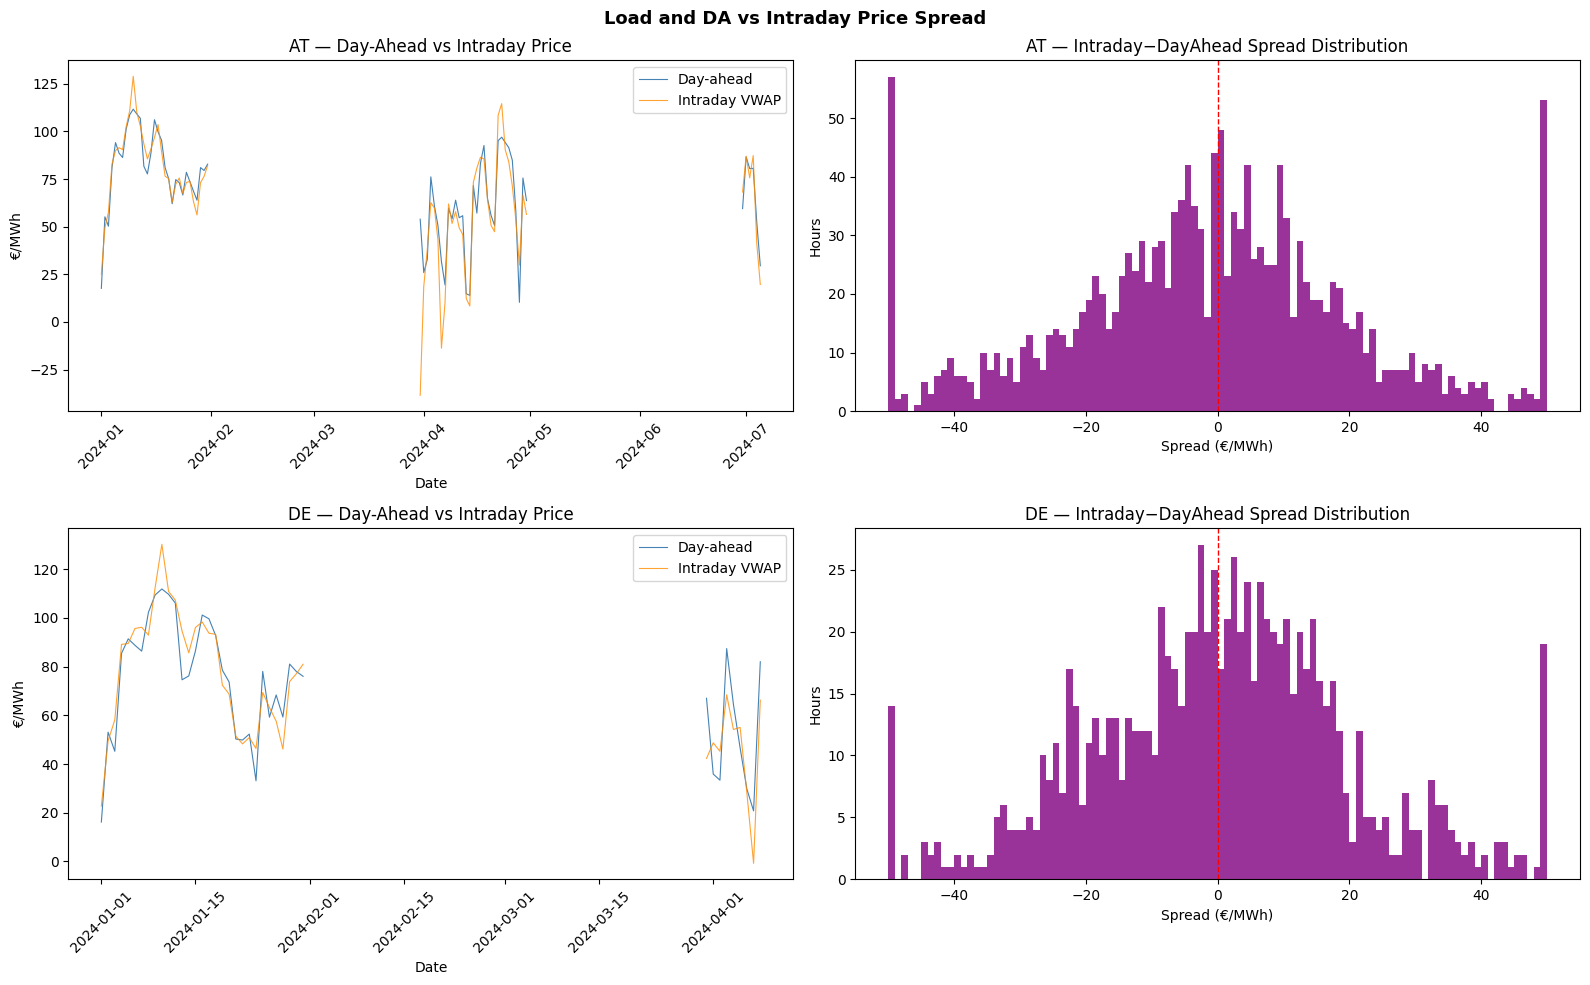

Saved → ../reports/da_id_spread.png


In [95]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Load and DA vs Intraday Price Spread", fontsize=13, fontweight="bold")

for row, (name, trades, da, load) in enumerate([
    ("AT", df_at_trades, da_at, load_at),
    ("DE", df_de_trades, da_de, load_de)
]):
    # Hourly VWAP from intraday trades
    vwap = (
        trades.groupby(trades["time"].dt.floor("h"))
        .apply(lambda g: np.average(g["price"], weights=g["quantity"]),
               include_groups=False)
        .rename("intraday_vwap")
        .reset_index()
    )
    vwap.columns = ["time", "intraday_vwap"]
    vwap["time"] = pd.to_datetime(vwap["time"]).dt.tz_localize(None)

    da_clean = da.copy()
    da_clean["time"] = pd.to_datetime(da_clean["time"]).dt.tz_localize(None)

    merged = vwap.merge(da_clean[["time", "day_ahead_price"]], on="time", how="inner")
    merged["spread"] = merged["intraday_vwap"] - merged["day_ahead_price"]

    # Plot 1 — DA vs ID price daily average
    ax = axes[row, 0]
    daily = merged.set_index("time").resample("D").mean()
    ax.plot(daily.index, daily["day_ahead_price"],
            linewidth=0.8, label="Day-ahead", color="steelblue")
    ax.plot(daily.index, daily["intraday_vwap"],
            linewidth=0.8, label="Intraday VWAP", color="darkorange", alpha=0.8)
    ax.set_title(f"{name} — Day-Ahead vs Intraday Price")
    ax.set_xlabel("Date")
    ax.set_ylabel("€/MWh")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

    # Plot 2 — Spread distribution
    ax = axes[row, 1]
    spread_clipped = merged["spread"].clip(-50, 50)
    ax.hist(spread_clipped, bins=100, color="purple", edgecolor="none", alpha=0.8)
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.set_title(f"{name} — Intraday−DayAhead Spread Distribution")
    ax.set_xlabel("Spread (€/MWh)")
    ax.set_ylabel("Hours")

plt.tight_layout()
plt.savefig("../reports/da_id_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/da_id_spread.png")

In [96]:
# Check the actual spread values before clipping
at_vwap = (
    df_at_trades.groupby(df_at_trades["time"].dt.floor("h"))
    .apply(lambda g: np.average(g["price"], weights=g["quantity"]),
           include_groups=False)
    .rename("intraday_vwap")
    .reset_index()
)
at_vwap.columns = ["time", "intraday_vwap"]
at_vwap["time"] = pd.to_datetime(at_vwap["time"]).dt.tz_localize(None)

da_at_clean = da_at.copy()
da_at_clean["time"] = pd.to_datetime(da_at_clean["time"]).dt.tz_localize(None)

at_merged = at_vwap.merge(da_at_clean[["time", "day_ahead_price"]], on="time", how="inner")
at_merged["spread"] = at_merged["intraday_vwap"] - at_merged["day_ahead_price"]

print("Spread statistics:")
print(at_merged["spread"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print()
print(f"Hours with spread > 50  : {(at_merged['spread'] > 50).sum()}")
print(f"Hours with spread < -50 : {(at_merged['spread'] < -50).sum()}")
print()
print("Top 10 largest spreads:")
print(at_merged.nlargest(10, "spread")[["time", "intraday_vwap", "day_ahead_price", "spread"]])

Spread statistics:
count    1577.000000
mean       -1.794785
std        27.946305
min      -296.497680
1%        -86.367503
5%        -41.486702
25%       -14.169441
50%        -0.531492
75%        11.491207
95%        38.891768
99%        69.966381
max       126.536733
Name: spread, dtype: float64

Hours with spread > 50  : 51
Hours with spread < -50 : 54

Top 10 largest spreads:
                    time  intraday_vwap  day_ahead_price      spread
1406 2024-04-28 12:00:00       8.796733          -117.74  126.536733
1409 2024-04-28 15:00:00      53.453991           -52.43  105.883991
1466 2024-06-30 15:00:00      98.440000             0.00   98.440000
1408 2024-04-28 14:00:00      31.600523           -65.06   96.660523
1467 2024-06-30 16:00:00      95.724375             0.94   94.784375
933  2024-04-08 14:00:00      79.994960            -3.98   83.974960
1273 2024-04-22 18:00:00     191.365362           107.90   83.465362
1114 2024-04-16 03:00:00      90.504011             9.43   81.07

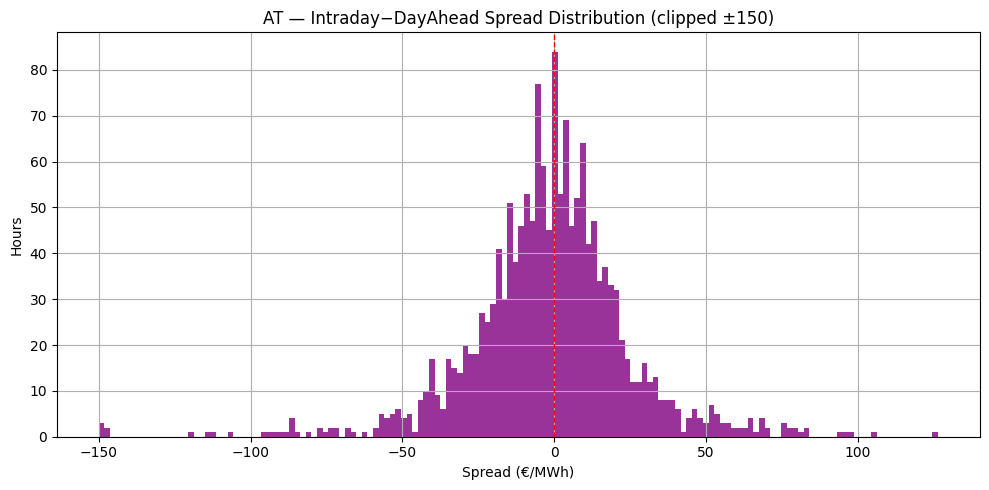

April 28 2024 — extreme spread event:
                    time  intraday_vwap  day_ahead_price      spread
1394 2024-04-28 00:00:00      36.329940            56.39  -20.060060
1395 2024-04-28 01:00:00      17.322708            45.67  -28.347292
1396 2024-04-28 02:00:00      12.998336            39.60  -26.601664
1397 2024-04-28 03:00:00       8.997496            30.80  -21.802504
1398 2024-04-28 04:00:00      18.264571            26.20   -7.935429
1399 2024-04-28 05:00:00       7.072601            24.93  -17.857399
1400 2024-04-28 06:00:00      -9.175905             9.92  -19.095905
1401 2024-04-28 07:00:00      -0.269359             0.10   -0.369359
1402 2024-04-28 08:00:00       6.203867            -0.07    6.273867
1403 2024-04-28 09:00:00     -14.010004            -1.02  -12.990004
1404 2024-04-28 10:00:00     -26.308801           -16.71   -9.598801
1405 2024-04-28 11:00:00     -14.032001           -36.83   22.797999
1406 2024-04-28 12:00:00       8.796733          -117.74  126.536

In [97]:
# Show unclipped to see true distribution
fig, ax = plt.subplots(figsize=(10, 5))
at_merged["spread"].clip(-150, 150).hist(bins=150, color="purple", 
                                          edgecolor="none", alpha=0.8, ax=ax)
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_title("AT — Intraday−DayAhead Spread Distribution (clipped ±150)")
ax.set_xlabel("Spread (€/MWh)")
ax.set_ylabel("Hours")
plt.tight_layout()
plt.savefig("../reports/da_id_spread_AT_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the April 28 event
print("April 28 2024 — extreme spread event:")
print(at_merged[at_merged["time"].dt.date.astype(str) == "2024-04-28"][
    ["time", "intraday_vwap", "day_ahead_price", "spread"]
])

Spread = Intraday price − Day-ahead price
It answers one question: how much did the market change its mind between the day before and actual delivery?

Spread = 0    → market was right, DA = intraday

Spread > 0    → intraday MORE expensive than DA
               → less supply arrived than expected
               → or more demand than expected

Spread < 0    → intraday CHEAPER than DA  ←  chart leans left
               → more supply arrived than expected
               → typically: more wind/solar than forecast
